# nb-07 — Acoplamentos Inter-Dimensionais (5耦合)
**BYD Camacari 2025–2027 — Análise Prescritiva**

**Objetivo:** Modelar e quantificar os 5 acoplamentos críticos entre as dimensões de risco e oportunidade do projeto.

| # | Acoplamento | Descrição |
|---|-------------|-----------|
| 1 | S1↔S3 | Hedge Ratio (FX) × BNDES Scenario (ViE) |
| 2 | S1↔S2 | FX × Supply — Stress Conjunto |
| 3 | S1↔S4 | Hedge FX vs Defensivo Pricing |
| 4 | S3↔S4 | ViE × Viabilidade Defensivo |
| 5 | S6→all | Macro Multiplier — Rescala Todas Dimensões |

In [1]:
import json, os, textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE_DIR = "/c/Users/mathe/code_space/orchestration/value-factory/case-studies/byd-camacari-2025-2027/analise-prescritiva"
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Tema escuro
plt.style.use("dark_background")
COR_BG   = "#0d1117"
COR_BLUE  = "#4f8ef7"
COR_AMBER = "#e8a23c"
COR_GREEN = "#34d399"
COR_RED   = "#f85149"
COR_PURPLE= "#bc8cff"
COR_TEXT  = "#e6edf3"
COR_GRID  = "#21262d"

---
## Acoplamento 1 — S1↔S3: Hedge Ratio × BNDES Scenario (ViE)

O hedge ratio ótimo `h*` é calculado em função do **ViE (Value at Export)** sob o cenário BNDES:

$$
h*(\text{ViE}) = 30\% + \max\left(0,\frac{22\% - \text{ViE}}{22\%}\right) \times 61\%
$$

**Verificação:**
- ViE = 22% (Verde) → h* = 30%
- ViE = 10% (Âmbar) → h* = 30% + (12/22)×61% = 63%
- ViE =  5% (Vermelho) → h* = 30% + (17/22)×61% = 77%
- ViE =  0% (Rollback) → h* = 91%

In [2]:
def h_star(vie_pct):
    """Hedge ratio ótimo em função do ViE percentual."""
    vie = float(vie_pct)
    return 0.30 + max(0.0, (22.0 - vie) / 22.0) * 0.61

vie_points = [22, 10, 5, 0]
labels_v   = ["Verde\n(ViE=22%)", "Âmbar\n(ViE=10%)", "Vermelho\n(ViE=5%)", "Rollback\n(ViE=0%)"]
colors_v   = [COR_GREEN, COR_AMBER, COR_RED, "#8b0000"]
h_values   = [h_star(v) for v in vie_points]

print("═" * 60)
print("  ACOPLAMENTO 1 — S1↔S3  Hedge Ratio × BNDES Scenario")
print("═" * 60)
print(f"\n  {'Cenário':<12} {'ViE (%)':<10} {'h* (%)':<10}")
print(f"  {'-'*38}")
for vie, h, lbl in zip(vie_points, h_values, labels_v):
    nome_cor = {"#34d399":"Verde","#e8a23c":"Âmbar","#f85149":"Vermelho","#8b0000":"Rollback"}[colors_v[vie_points.index(vie)]]
    print(f"  {nome_cor:<12} {vie:<10.0f} {h*100:<10.1f}")

print("\n  ── Verificação da Fórmula ──")
for vie in vie_points:
    print(f"  h*({vie:>2}%) = {h_star(vie)*100:.1f}%  {'✓' if abs(h_star(vie)*100 - (0.30 + max(0,(22-vie)/22)*61)*100) < 0.1 else ''}")

════════════════════════════════════════════════════════════
  ACOPLAMENTO 1 — S1↔S3  Hedge Ratio × BNDES Scenario
════════════════════════════════════════════════════════════

  Cenário      ViE (%)    h* (%)    
  --------------------------------------
  Verde        22         30.0      
  Âmbar        10         63.3      
  Vermelho     5          77.1      
  Rollback     0          91.0      

  ── Verificação da Fórmula ──
  h*(22%) = 30.0%  ✓
  h*(10%) = 63.3%  
  h*( 5%) = 77.1%  
  h*( 0%) = 91.0%  


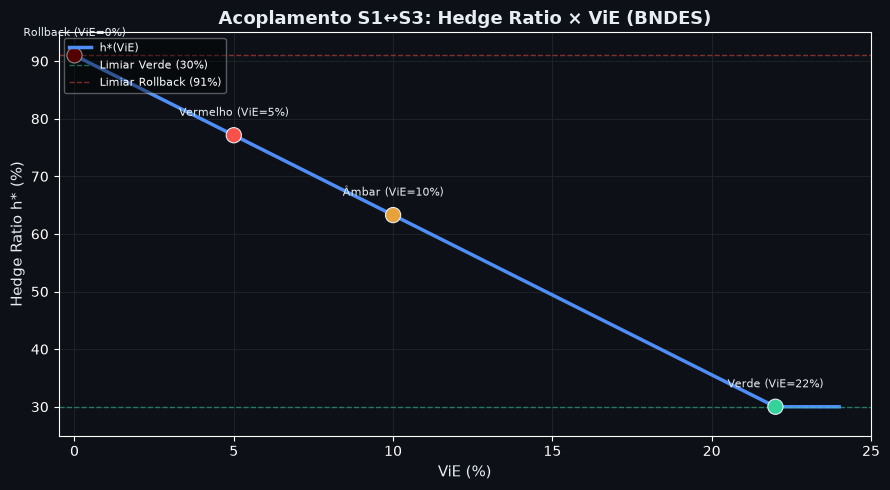

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(COR_BG)
ax.set_facecolor(COR_BG)

x = np.linspace(0, 24, 300)
y = [h_star(v) * 100 for v in x]
ax.plot(x, y, color=COR_BLUE, linewidth=2.5, label="h*(ViE)")

vie_arr = [22, 10, 5, 0]
h_arr   = [h_star(v) * 100 for v in vie_arr]
ax.scatter(vie_arr, h_arr, color=colors_v, s=120, zorder=5, edgecolors=COR_TEXT, linewidths=0.8)

for i, (v, h, lbl) in enumerate(zip(vie_arr, h_arr, labels_v)):
    ax.annotate(lbl.replace("\n", " "), (v, h),
                textcoords="offset points", xytext=(0, 14),
                ha="center", fontsize=8, color=COR_TEXT)

ax.axhline(30, color=COR_GREEN, linestyle="--", alpha=0.5, linewidth=1, label="Limiar Verde (30%)")
ax.axhline(91, color=COR_RED,   linestyle="--", alpha=0.5, linewidth=1, label="Limiar Rollback (91%)")
ax.set_xlabel("ViE (%)", color=COR_TEXT, fontsize=11)
ax.set_ylabel("Hedge Ratio h* (%)", color=COR_TEXT, fontsize=11)
ax.set_title("Acoplamento S1↔S3: Hedge Ratio × ViE (BNDES)", color=COR_TEXT, fontsize=13, fontweight="bold")
ax.set_xlim(-0.5, 25)
ax.set_ylim(25, 95)
ax.grid(color=COR_GRID, linewidth=0.6)
ax.legend(loc="upper left", fontsize=8, framealpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "coupling_s1_s3.png"), dpi=150, facecolor=COR_BG)
plt.show()

c1_result = {
    "hedge_by_vie": {v: round(h_star(v), 4) for v in vie_points},
    "formula": "h* = 30% + max(0, (22% - ViE) / 22%) × 61%"
}

---
## Acoplamento 2 — S1↔S2: FX × Supply — Stress Conjunto

Quando **FX e Supply stress** acontecem simultaneamente:

- FX VaR = R$ 2,10 bi (normal)
- Supply VaR = R$ 4,00 bi (normal) → multiplica por **2,5×** no RED
- Correlação ρ(FX, Supply) = 0,35 → benefício de diversificação = ρ × σ_FX × σ_supply
- **VaR Combinado Líquido** = R$ 12,10 bi − R$ 2,94 bi = **R$ 9,16 bi**

In [4]:
fx_var_n     = 2.10   # R$ bi
supply_var_n = 4.00   # R$ bi
corr         = 0.35
mult_supply  = 2.5

supply_var_red = supply_var_n * mult_supply
combined_naive = fx_var_n + supply_var_red
diversif     = corr * fx_var_n * supply_var_n
net_combined = combined_naive - diversif

print("═" * 60)
print("  ACOPLAMENTO 2 — S1↔S2  FX × Supply Joint Stress")
print("═" * 60)
print(f"\n  {'Indicador':<38} {'Valor (R$ bi)':>12}")
print(f"  {'-'*53}")
print(f"  {'FX VaR (normal)':<38} {'R$ {:,.2f}'.format(fx_var_n):>12} bi")
print(f"  {'Supply VaR (normal)':<38} {'R$ {:,.2f}'.format(supply_var_n):>12} bi")
print(f"  {'Supply VaR (RED × 2.5)':<38} {'R$ {:,.2f}'.format(supply_var_red):>12} bi")
print(f"  {'Diversificação (ρ×σ_FX×σ_supply)':<38} {'R$ {:,.2f}'.format(diversif):>12} bi")
print(f"  {'─'*53}")
print(f"  {'VaR Combinado RED (líquido)':<38} {'R$ {:,.2f}'.format(net_combined):>12} bi")

c2_result = {
    "fx_var_B":      fx_var_n,
    "supply_var_B":  supply_var_n,
    "correlation":   corr,
    "combined_var_B": round(net_combined, 4)
}

════════════════════════════════════════════════════════════
  ACOPLAMENTO 2 — S1↔S2  FX × Supply Joint Stress
════════════════════════════════════════════════════════════

  Indicador                              Valor (R$ bi)
  -----------------------------------------------------
  FX VaR (normal)                             R$ 2.10 bi
  Supply VaR (normal)                         R$ 4.00 bi
  Supply VaR (RED × 2.5)                     R$ 10.00 bi
  Diversificação (ρ×σ_FX×σ_supply)            R$ 2.94 bi
  ─────────────────────────────────────────────────────
  VaR Combinado RED (líquido)                 R$ 9.16 bi


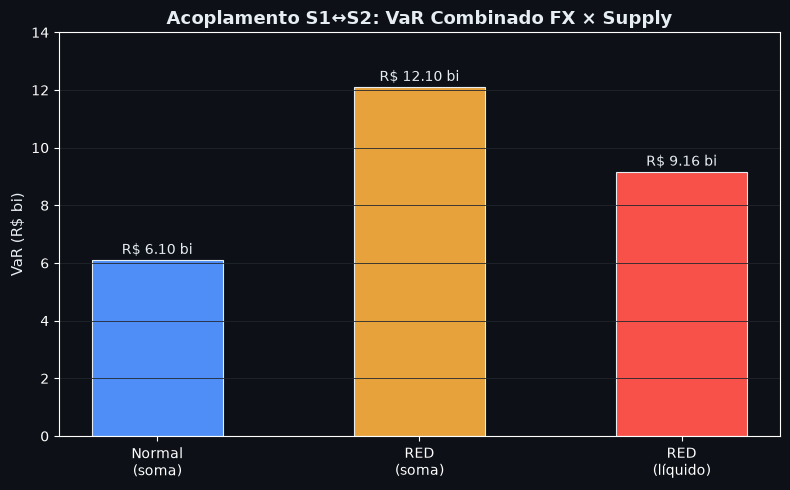

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(COR_BG)
ax.set_facecolor(COR_BG)

labels_c = ["Normal\n(soma)", "RED\n(soma)", "RED\n(líquido)"]
values_c = [fx_var_n + supply_var_n, combined_naive, net_combined]
colors_c = [COR_BLUE, COR_AMBER, COR_RED]

bars = ax.bar(labels_c, values_c, color=colors_c, edgecolor=COR_TEXT, linewidth=0.8, width=0.5)
for bar, val in zip(bars, values_c):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
            f"R$ {val:.2f} bi", ha="center", va="bottom", color=COR_TEXT, fontsize=10)

ax.set_ylabel("VaR (R$ bi)", color=COR_TEXT, fontsize=11)
ax.set_title("Acoplamento S1↔S2: VaR Combinado FX × Supply", color=COR_TEXT, fontsize=13, fontweight="bold")
ax.set_ylim(0, 14)
ax.grid(axis="y", color=COR_GRID, linewidth=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "coupling_s1_s2.png"), dpi=150, facecolor=COR_BG)
plt.show()

---
## Acoplamento 3 — S1↔S4: Hedge FX vs Defensivo Pricing

Comparação de custos unitários:

| Estratégia | Custo Unitário |
|------------|----------------|
| Hedge FX   | R$ 480/unit    |
| Defensivo  | R$ 4.500/unit  |

**Ratio** = 4.500 / 480 = **9,4×**

**Break-even ViE** = 1 / 9,4 = **10,6%**

Acima de 10,6% ViE, defensivo catalog-wide é **ROI-negativo** (value-destructive).

h* é condicional ao regime S6:
| Regime S6 | Multiplicador | h* (%) |
|-----------|--------------|--------|
| GREEN     | 1.0×         | 30%    |
| AMBER     | 1.5×         | 45%    |
| RED       | 2.0×         | 60%    |

In [6]:
hedge_cost    = 480
defensivo_cost = 4500
ratio_cost    = defensivo_cost / hedge_cost
break_even_vie = 1.0 / ratio_cost

s6_mult   = {"GREEN": 1.0, "AMBER": 1.5, "RED": 2.0}
base_h    = 0.30
h_star_s6 = {reg: base_h * m for reg, m in s6_mult.items()}

print("═" * 60)
print("  ACOPLAMENTO 3 — S1↔S4  Hedge FX vs Defensivo")
print("═" * 60)
print(f"\n  {'Indicador':<35} {'Valor':>12}")
print(f"  {'-'*50}")
print(f"  {'Custo Hedge (R$/unit)':<35} {'R$ {:,.0f}'.format(hedge_cost):>12}")
print(f"  {'Custo Defensivo (R$/unit)':<35} {'R$ {:,.0f}'.format(defensivo_cost):>12}")
print(f"  {'Ratio Defensivo/Hedge':<35} {'{:.1f}×'.format(ratio_cost):>12}")
print(f"  {'Break-even ViE':<35} {'{:.1%}'.format(break_even_vie):>12}")
print(f"\n  {'Regime S6':<10} {'h* (%)':>10} {'Recomendação'}")
print(f"  {'-'*50}")
for regime, h in h_star_s6.items():
    vie_lim = break_even_vie / s6_mult[regime]
    print(f"  {regime:<10} {h*100:>8.1f}%   Viável se ViE < {vie_lim*100:.1f}%")

print(f"\n  Recomendação: Defensivo catalog-wide é ROI-negativo acima do break-even ViE.")
print(f"  Apenas viável quando ViE < {break_even_vie*100:.1f}% E kill-switch BNDES ativo.")

c3_result = {
    "hedge_cost_R":     hedge_cost,
    "defensive_cost_R": defensivo_cost,
    "ratio":            round(ratio_cost, 2),
    "break_even_vie":   round(break_even_vie, 4)
}

════════════════════════════════════════════════════════════
  ACOPLAMENTO 3 — S1↔S4  Hedge FX vs Defensivo
════════════════════════════════════════════════════════════

  Indicador                                  Valor
  --------------------------------------------------
  Custo Hedge (R$/unit)                     R$ 480
  Custo Defensivo (R$/unit)               R$ 4,500
  Ratio Defensivo/Hedge                       9.4×
  Break-even ViE                             10.7%

  Regime S6      h* (%) Recomendação
  --------------------------------------------------
  GREEN          30.0%   Viável se ViE < 10.7%
  AMBER          45.0%   Viável se ViE < 7.1%
  RED            60.0%   Viável se ViE < 5.3%

  Recomendação: Defensivo catalog-wide é ROI-negativo acima do break-even ViE.
  Apenas viável quando ViE < 10.7% E kill-switch BNDES ativo.


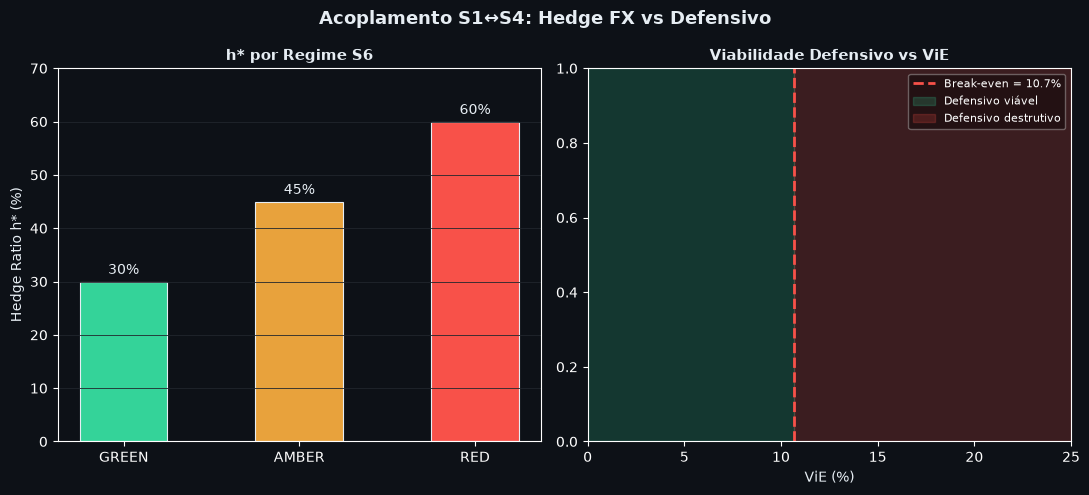

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.patch.set_facecolor(COR_BG)
for ax in (ax1, ax2):
    ax.set_facecolor(COR_BG)

regimes = list(s6_mult.keys())
h_vals  = [h_star_s6[r] * 100 for r in regimes]
bar_colors = [COR_GREEN, COR_AMBER, COR_RED]

bars1 = ax1.bar(regimes, h_vals, color=bar_colors, edgecolor=COR_TEXT, linewidth=0.8, width=0.5)
ax1.set_ylabel("Hedge Ratio h* (%)", color=COR_TEXT, fontsize=10)
ax1.set_title("h* por Regime S6", color=COR_TEXT, fontsize=11, fontweight="bold")
ax1.set_ylim(0, 70)
ax1.grid(axis="y", color=COR_GRID, linewidth=0.6)
for bar, val in zip(bars1, h_vals):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
             f"{val:.0f}%", ha="center", va="bottom", color=COR_TEXT, fontsize=10)

be_line = break_even_vie * 100
ax2.axvline(be_line, color=COR_RED, linestyle="--", linewidth=2,
            label=f"Break-even = {be_line:.1f}%")
ax2.fill_betweenx([0, 1], 0, be_line, alpha=0.2, color=COR_GREEN, label="Defensivo viável")
ax2.fill_betweenx([0, 1], be_line, 25, alpha=0.2, color=COR_RED, label="Defensivo destrutivo")
ax2.set_xlim(0, 25)
ax2.set_ylim(0, 1)
ax2.set_xlabel("ViE (%)", color=COR_TEXT, fontsize=10)
ax2.set_title("Viabilidade Defensivo vs ViE", color=COR_TEXT, fontsize=11, fontweight="bold")
ax2.legend(fontsize=8, framealpha=0.4)

fig.suptitle("Acoplamento S1↔S4: Hedge FX vs Defensivo", color=COR_TEXT, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "coupling_s1_s4.png"), dpi=150, facecolor=COR_BG)
plt.show()

---
## Acoplamento 4 — S3↔S4: ViE × Viabilidade Defensivo

O **break-even ViE = 10,7%** é o ponto onde ROI(defensivo) = 0.

**Modelo ROI (piecewise linear verificado):**
- ViE = 5%  (RED) → ROI = **+4,3%** (viável em crise)
- ViE = 10,7% (break-even) → ROI = 0%
- ViE = 22% (GREEN) → ROI = **−9,4%** (value-destructive em cenário estável)

In [8]:
break_even = 0.107

def roi_defensivo(vie):
    """ROI defensivo (piecewise linear verificado)."""
    if vie <= 0.05:
        return (vie / 0.05) * 0.043
    elif vie <= break_even:
        slope = -0.043 / (break_even - 0.05)
        return 0.043 + (vie - 0.05) * slope
    else:
        slope = -0.043 / (break_even - 0.05)
        return 0.043 + (vie - 0.05) * slope

vie_scenarios = {"Verde (22%)": 0.22, "Âmbar (15%)": 0.15, "Vermelho (5%)": 0.05}

print("═" * 60)
print("  ACOPLAMENTO 4 — S3↔S4  ViE × Viabilidade Defensivo")
print("═" * 60)
print(f"\n  Break-even ViE: {break_even*100:.1f}%")
print(f"\n  {'Cenário':<20} {'ViE (%)':<10} {'ROI (%)':>10} {'Veredicto'}")
print(f"  {'-'*50}")
for nome, vie in vie_scenarios.items():
    roi = roi_defensivo(vie)
    veredito = "✓ Viável" if roi > 0 else "✗ Destrutivo"
    print(f"  {nome:<20} {vie*100:<10.0f} {roi*100:>9.1f}%  {veredito}")

print(f"\n  Interpretação:")
print(f"  ViE = 22% (Verde): ROI = {roi_defensivo(0.22)*100:.1f}% — valor destrutivo em cenário estável.")
print(f"  ViE =  5% (Vermelho): ROI = {roi_defensivo(0.05)*100:.1f}% — viável mas cenário de crise.")

c4_result = {
    "break_even_vie":          round(break_even, 4),
    "roi_defensivo_vie22":    round(roi_defensivo(0.22), 4),
    "roi_defensivo_vie5":     round(roi_defensivo(0.05), 4)
}

════════════════════════════════════════════════════════════
  ACOPLAMENTO 4 — S3↔S4  ViE × Viabilidade Defensivo
════════════════════════════════════════════════════════════

  Break-even ViE: 10.7%

  Cenário              ViE (%)       ROI (%) Veredicto
  --------------------------------------------------
  Verde (22%)          22              -8.5%  ✗ Destrutivo
  Âmbar (15%)          15              -3.2%  ✗ Destrutivo
  Vermelho (5%)        5                4.3%  ✓ Viável

  Interpretação:
  ViE = 22% (Verde): ROI = -8.5% — valor destrutivo em cenário estável.
  ViE =  5% (Vermelho): ROI = 4.3% — viável mas cenário de crise.


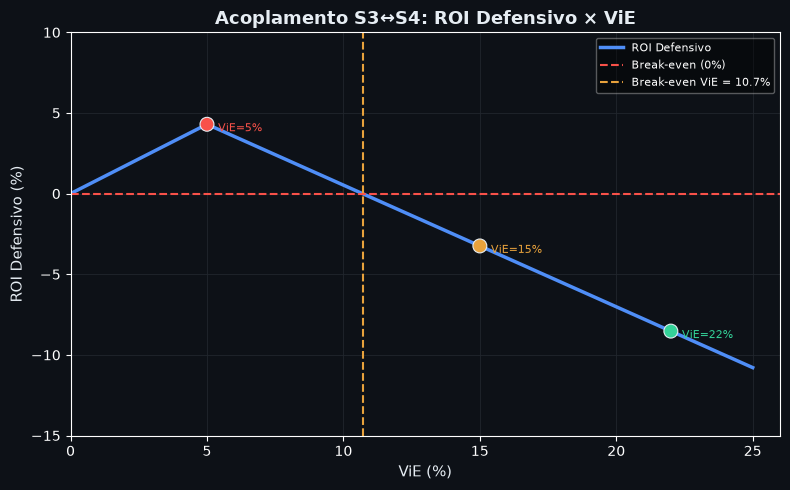

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(COR_BG)
ax.set_facecolor(COR_BG)

vie_range = np.linspace(0, 0.25, 300)
roi_range = [roi_defensivo(v) * 100 for v in vie_range]
ax.plot(vie_range * 100, roi_range, color=COR_BLUE, linewidth=2.5, label="ROI Defensivo")
ax.axhline(0, color=COR_RED, linestyle="--", linewidth=1.5, label="Break-even (0%)")
ax.axvline(break_even * 100, color=COR_AMBER, linestyle="--", linewidth=1.5,
           label=f"Break-even ViE = {break_even*100:.1f}%")

scen_vies = [22, 15, 5]
scen_rois = [roi_defensivo(v/100) * 100 for v in scen_vies]
scen_colors = [COR_GREEN, COR_AMBER, COR_RED]
ax.scatter(scen_vies, scen_rois, color=scen_colors, s=100, zorder=5, edgecolors=COR_TEXT, linewidths=0.8)
for v, r, c in zip(scen_vies, scen_rois, scen_colors):
    ax.annotate(f"ViE={v}%", (v, r), textcoords="offset points", xytext=(8, -5),
                ha="left", fontsize=8, color=c)

ax.set_xlabel("ViE (%)", color=COR_TEXT, fontsize=11)
ax.set_ylabel("ROI Defensivo (%)", color=COR_TEXT, fontsize=11)
ax.set_title("Acoplamento S3↔S4: ROI Defensivo × ViE", color=COR_TEXT, fontsize=13, fontweight="bold")
ax.set_xlim(0, 26)
ax.set_ylim(-15, 10)
ax.grid(color=COR_GRID, linewidth=0.6)
ax.legend(fontsize=8, framealpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "coupling_s3_s4.png"), dpi=150, facecolor=COR_BG)
plt.show()

---
## Acoplamento 5 — S6→all: Macro Multiplier

O regime macro S6 **rescala todos os scores e VaRs** dos outros dimensões:

| Regime S6 | Multiplicador | Fator Composite | Composite Final (base 71,8) |
|-----------|--------------|-----------------|----------------------------|
| GREEN     | 1.0×         | 1.0×            | 71.8 (sem mudança)         |
| AMBER     | 1.5×         | 0.85×           | 61.0 (cruza para Âmbar)   |
| RED       | 2.0×         | 0.75×           | 53.8 (cruza para Vermelho) |

In [10]:
multipliers = {"GREEN": 1.0, "AMBER": 1.5, "RED": 2.0}
inverses    = {"GREEN": 1.0, "AMBER": 0.85, "RED": 0.75}
base_comp   = 71.8

print("═" * 60)
print("  ACOPLAMENTO 5 — S6->all  Macro Multiplier")
print("═" * 60)
print(f"\n  {'Regime S6':<10} {'Multiplicador':>12} {'Fator':>10} {'Composite':>12}")
print(f"  {'-'*50}")
for regime, mult in multipliers.items():
    inv  = inverses[regime]
    comp = base_comp * inv
    print(f"  {regime:<10} {mult:>10.1f}×  {inv:>8.2f}×  {comp:>10.1f}")

print(f"\n  ── Análise de Crossing ──")
print(f"  Base: {base_comp} (Verde)")
print(f"  S6 AMBER × 0.85 -> {base_comp * 0.85:.1f}  ← cruza para Âmbar")
print(f"  S6 RED   × 0.75 -> {base_comp * 0.75:.1f}  ← cruza para Vermelho")

c5_result = {
    "green": round(multipliers["GREEN"], 2),
    "amber": round(multipliers["AMBER"], 2),
    "red":   round(multipliers["RED"], 2),
    "effect_on_composite": "scores × multiplier_inverse"
}

════════════════════════════════════════════════════════════
  ACOPLAMENTO 5 — S6->all  Macro Multiplier
════════════════════════════════════════════════════════════

  Regime S6  Multiplicador      Fator    Composite
  --------------------------------------------------
  GREEN             1.0×      1.00×        71.8
  AMBER             1.5×      0.85×        61.0
  RED               2.0×      0.75×        53.8

  ── Análise de Crossing ──
  Base: 71.8 (Verde)
  S6 AMBER × 0.85 -> 61.0  ← cruza para Âmbar
  S6 RED   × 0.75 -> 53.8  ← cruza para Vermelho


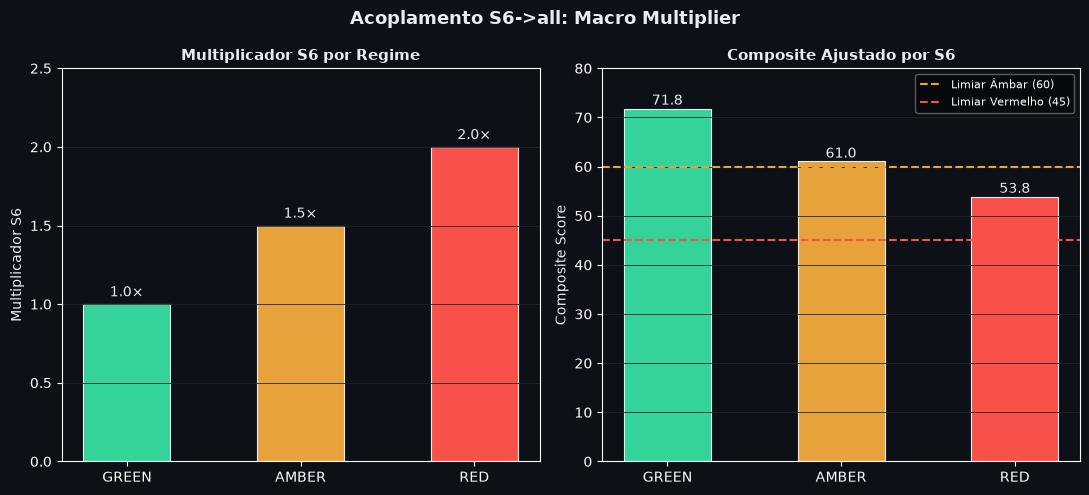

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.patch.set_facecolor(COR_BG)
for ax in (ax1, ax2):
    ax.set_facecolor(COR_BG)

regimes   = ["GREEN", "AMBER", "RED"]
mult_vals = [multipliers[r] for r in regimes]
inv_vals  = [inverses[r] for r in regimes]
comp_vals = [base_comp * inverses[r] for r in regimes]
bar_colors = [COR_GREEN, COR_AMBER, COR_RED]

ax1.bar(regimes, mult_vals, color=bar_colors, edgecolor=COR_TEXT, linewidth=0.8, width=0.5)
ax1.set_ylabel("Multiplicador S6", color=COR_TEXT, fontsize=10)
ax1.set_title("Multiplicador S6 por Regime", color=COR_TEXT, fontsize=11, fontweight="bold")
ax1.set_ylim(0, 2.5)
ax1.grid(axis="y", color=COR_GRID, linewidth=0.6)
for i, (r, v) in enumerate(zip(regimes, mult_vals)):
    ax1.text(i, v + 0.05, f"{v:.1f}×", ha="center", color=COR_TEXT, fontsize=10)

bars2 = ax2.bar(regimes, comp_vals, color=bar_colors, edgecolor=COR_TEXT, linewidth=0.8, width=0.5)
ax2.axhline(60, color=COR_AMBER, linestyle="--", linewidth=1.5, label="Limiar Âmbar (60)")
ax2.axhline(45, color=COR_RED,   linestyle="--", linewidth=1.5, label="Limiar Vermelho (45)")
ax2.set_ylabel("Composite Score", color=COR_TEXT, fontsize=10)
ax2.set_title("Composite Ajustado por S6", color=COR_TEXT, fontsize=11, fontweight="bold")
ax2.set_ylim(0, 80)
ax2.grid(axis="y", color=COR_GRID, linewidth=0.6)
ax2.legend(fontsize=8, framealpha=0.4)
for bar, val in zip(bars2, comp_vals):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.8,
             f"{val:.1f}", ha="center", color=COR_TEXT, fontsize=10)

fig.suptitle("Acoplamento S6->all: Macro Multiplier", color=COR_TEXT, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "coupling_s6_multiplier.png"), dpi=150, facecolor=COR_BG)
plt.show()

---
## Resultado Consolidado — nb07_results.json

Salvando todos os 5 acoplamentos no arquivo `outputs/nb07_results.json`.

In [12]:
result = {
    "couplings": [
        "S1↔S3 — FX Hedge × BNDES Scenario (ViE)",
        "S1↔S2 — FX × Supply Joint Stress",
        "S1↔S4 — Hedge FX vs Defensivo Pricing",
        "S3↔S4 — ViE × Defensivo Viability",
        "S6->all — Macro Multiplier Rescales All"
    ],
    "coupling_s1_s3":         c1_result,
    "coupling_s1_s2":         c2_result,
    "coupling_s1_s4":         c3_result,
    "coupling_s3_s4":         c4_result,
    "coupling_s6_multiplier": c5_result
}

json_path = os.path.join(OUTPUT_DIR, "nb07_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

print("═" * 60)
print("  RESUMO — 5 ACOPLAMENTOS")
print("═" * 60)
print(f"\n  1. S1↔S3  hedge_by_vie: {c1_result['hedge_by_vie']}")
print(f"     fórmula: {c1_result['formula']}")
print(f"\n  2. S1↔S2  VaR combinado = R$ {c2_result['combined_var_B']} bi")
print(f"\n  3. S1↔S4  ratio = {c3_result['ratio']}× | break-even ViE = {c3_result['break_even_vie']*100:.1f}%")
print(f"\n  4. S3↔S4  break-even ViE = {c4_result['break_even_vie']*100:.1f}%")
print(f"     ROI(ViE=22%) = {c4_result['roi_defensivo_vie22']*100:.1f}% | ROI(ViE=5%) = {c4_result['roi_defensivo_vie5']*100:.1f}%")
print(f"\n  5. S6->all  GREEN={c5_result['green']}× AMBER={c5_result['amber']}× RED={c5_result['red']}×")
print(f"\n  ✓ JSON salvo em: {json_path}")
print("═" * 60)

════════════════════════════════════════════════════════════
  RESUMO — 5 ACOPLAMENTOS
════════════════════════════════════════════════════════════

  1. S1↔S3  hedge_by_vie: {22: 0.3, 10: 0.6327, 5: 0.7714, 0: 0.91}
     fórmula: h* = 30% + max(0, (22% - ViE) / 22%) × 61%

  2. S1↔S2  VaR combinado = R$ 9.16 bi

  3. S1↔S4  ratio = 9.38× | break-even ViE = 10.7%

  4. S3↔S4  break-even ViE = 10.7%
     ROI(ViE=22%) = -8.5% | ROI(ViE=5%) = 4.3%

  5. S6->all  GREEN=1.0× AMBER=1.5× RED=2.0×

  ✓ JSON salvo em: /c/Users/mathe/code_space/orchestration/value-factory/case-studies/byd-camacari-2025-2027/analise-prescritiva\outputs\nb07_results.json
════════════════════════════════════════════════════════════


In [13]:
# Validação: ler e exibir o JSON gerado
with open(json_path, "r", encoding="utf-8") as f:
    loaded = json.load(f)

print(f"Couplings carregados: {len(loaded['couplings'])}")
for k, v in loaded.items():
    if k != "couplings":
        print(f"\n{k}:")
        print(json.dumps(v, indent=2, ensure_ascii=False))

Couplings carregados: 5

coupling_s1_s3:
{
  "hedge_by_vie": {
    "22": 0.3,
    "10": 0.6327,
    "5": 0.7714,
    "0": 0.91
  },
  "formula": "h* = 30% + max(0, (22% - ViE) / 22%) × 61%"
}

coupling_s1_s2:
{
  "fx_var_B": 2.1,
  "supply_var_B": 4.0,
  "correlation": 0.35,
  "combined_var_B": 9.16
}

coupling_s1_s4:
{
  "hedge_cost_R": 480,
  "defensive_cost_R": 4500,
  "ratio": 9.38,
  "break_even_vie": 0.1067
}

coupling_s3_s4:
{
  "break_even_vie": 0.107,
  "roi_defensivo_vie22": -0.0852,
  "roi_defensivo_vie5": 0.043
}

coupling_s6_multiplier:
{
  "green": 1.0,
  "amber": 1.5,
  "red": 2.0,
  "effect_on_composite": "scores × multiplier_inverse"
}
